In [26]:
import tensorflow as tf 
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt 

In [27]:
import numpy as np

In [28]:
Image_SIZE = 256
BATCH_SIZE = 32
channels = 3
EPOCHS = 50

In [29]:
dataset =  tf.keras.preprocessing.image_dataset_from_directory(
  "PlantVillage",
  shuffle=True,
  image_size=(Image_SIZE, Image_SIZE),
  batch_size = BATCH_SIZE 
  
)

Found 2152 files belonging to 3 classes.


In [30]:
class_names = dataset.class_names
class_names

['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']

In [31]:
len(dataset)

68

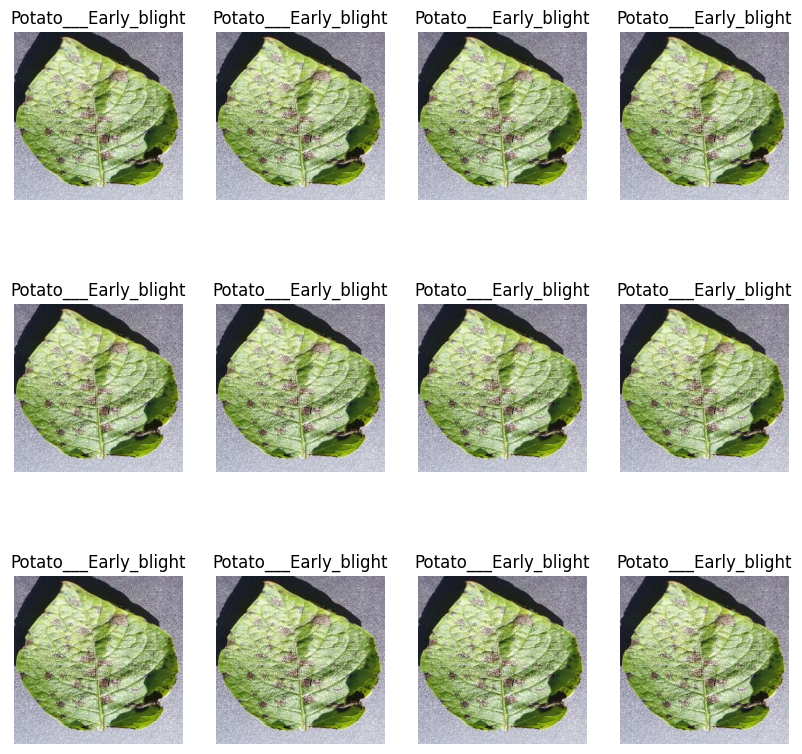

In [32]:
plt.figure(figsize=(10, 10))
for image_batch, label_batch in dataset.take(1):
    for i in range(12):
      ax =  plt.subplot(3, 4, i + 1)
      plt.imshow(image_batch[0].numpy().astype("uint8"))
      plt.title(class_names[label_batch[0]])
      plt.axis("off")

In [33]:
train_size = 0.8
dataset.take(10)
len(dataset)*train_size

54.400000000000006

In [34]:
train_ds = dataset.take(54)
len(train_ds)

54

In [35]:
test_ds = dataset.skip(54)
len(test_ds)

14

In [36]:
val_size = 0.1
len(dataset)*val_size

6.800000000000001

In [37]:
val_ds = test_ds.take(6)
len(val_ds)

6

In [38]:
test_ds = test_ds.skip(6)
len(test_ds)

8

In [39]:
def get_dataset_partitions_tf(ds, train_split=0.8, val_split=0.1, test_split=0.1, shuffle=True, shuffle_size=10000):
  assert (train_split + test_split + val_split) == 1

  ds_size = len(ds)

  if shuffle:
    ds = ds.shuffle(shuffle_size, seed=12)

  train_size = int(train_split * ds_size)
  val_size = int(val_split * ds_size)

  train_ds = ds.take(train_size)
  val_ds = ds.skip(train_size).take(val_size)
  test_ds = ds.skip(train_size).skip(val_size)

  return train_ds, val_ds, test_ds

In [40]:
train_ds, val_ds, test_ds = get_dataset_partitions_tf(dataset)

In [41]:
len(train_ds), len(val_ds), len(test_ds)

(54, 6, 8)

In [42]:
train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE) 
val_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

In [43]:
resize_and_rescale = tf.keras.Sequential([
    layers.Resizing(Image_SIZE, Image_SIZE),
    layers.Rescaling(1./255)
])

In [44]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
])

In [45]:
input_shape = (BATCH_SIZE, Image_SIZE, Image_SIZE, channels)

model = models.Sequential([
  resize_and_rescale, 
  data_augmentation,
  layers.Convolution2D(32, (3, 3), activation="relu", input_shape=input_shape),
  layers.MaxPooling2D((2, 2)),
  layers.Convolution2D(64, (3, 3), activation="relu"),
  layers.MaxPooling2D((2, 2)),
  layers.Convolution2D(128, (3, 3), activation="relu"),
  layers.MaxPooling2D((2, 2)),
  layers.Flatten(),
  layers.Dense(64, activation="relu"),
  layers.Dense(len(class_names), activation="softmax")
])

model.build(input_shape=input_shape)

In [46]:
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_3 (Sequential)       │ (32, 256, 256, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_4 (Sequential)       │ (32, 256, 256, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (32, 254, 254, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (32, 127, 127, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (32, 125, 125, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (32, 62, 62, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (32, 60, 60, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (32, 30, 30, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (32, 115200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (32, 64)               │     7,372,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (32, 3)                │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,466,307 (28.48 MB)

 Trainable params: 7,466,307 (28.48 MB)

 Non-trainable params: 0 (0.00 B)

In [47]:
model.compile(
    optimizer="adam",
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

In [48]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    batch_size = BATCH_SIZE,
    verbose=1
)

Epoch 1/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 132s 2s/step - accuracy: 0.7274 - loss: 0.7630 - val_accuracy: 0.8750 - val_loss: 0.4798
Epoch 2/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 139s 3s/step - accuracy: 0.8486 - loss: 0.4035 - val_accuracy: 0.8631 - val_loss: 0.3487
Epoch 3/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 96s 2s/step - accuracy: 0.9067 - loss: 0.2583 - val_accuracy: 0.8906 - val_loss: 0.2778
Epoch 4/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 102s 2s/step - accuracy: 0.8967 - loss: 0.2806 - val_accuracy: 0.8177 - val_loss: 0.3949
Epoch 5/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 80s 1s/step - accuracy: 0.9167 - loss: 0.2168 - val_accuracy: 0.8906 - val_loss: 0.2651
Epoch 6/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 79s 1s/step - accuracy: 0.9519 - loss: 0.1373 - val_accuracy: 0.9792 - val_loss: 0.0949
Epoch 7/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 89s 2s/step - accuracy: 0.9613 - loss: 0.0987 - val_accuracy: 0.9635 - val_loss: 0.0789
Epoch 8/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 112s 2s/step - accuracy: 0.9624 - loss: 0.1067 - val_accuracy: 0.9115 - val_l

In [49]:
scores = model.evaluate(test_ds)

8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 314ms/step - accuracy: 0.9727 - loss: 0.0600


In [50]:
history

In [51]:
history.params

{'verbose': 1, 'epochs': 50, 'steps': 54}

In [52]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

In [53]:
acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]

loss = history.history["loss"]
val_loss = history.history["val_loss"]

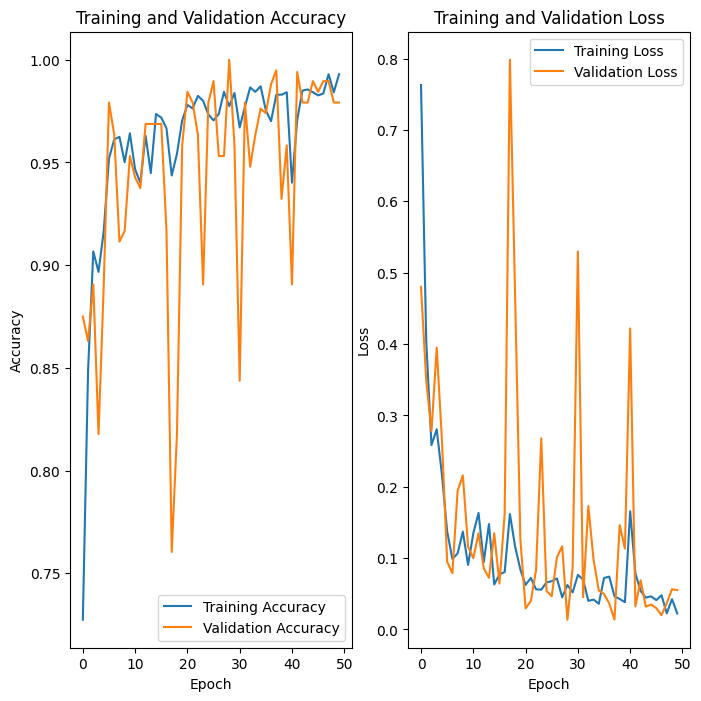

In [54]:
plt.figure(figsize=(8, 8))
plt.subplot(1,2,1)
plt.plot(range(EPOCHS), acc, label="Training Accuracy")
plt.plot(range(EPOCHS), val_acc, label="Validation Accuracy")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(loc="lower right") 

# loss 
plt.subplot(1,2,2)
plt.plot(range(EPOCHS), loss, label="Training Loss")  
plt.plot(range(EPOCHS), val_loss, label="Validation Loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(loc="upper right")
plt.show()


First image to predict
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
predicted label:  Potato___healthy


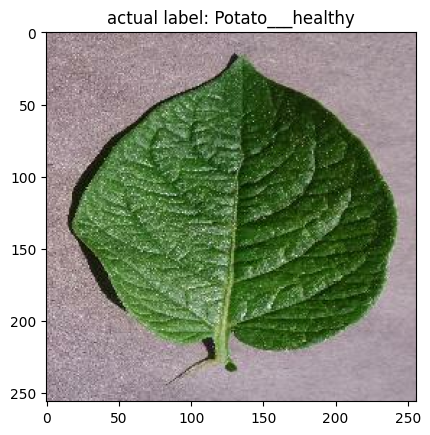

In [55]:
for image_batch, label_batch in test_ds.take(1):
    first_image = image_batch[0].numpy().astype("uint8")
    first_label = label_batch[0].numpy()
    print("First image to predict")
    plt.imshow(first_image)
    plt.title("actual label: " + class_names[first_label])
    batch_prediction = model.predict(image_batch)
    print("predicted label: ", class_names[np.argmax(batch_prediction[0])])
    

In [56]:
def predict(model, img):
    img_array = tf.keras.preprocessing.image.img_to_array(img[i].numpy())
    img_array = tf.expand_dims(img_array, 0) # Create a batch

    predictions = model.predict(img_array)
    
    predicted_class = class_names[np.argmax(predictions[0])]
    confidence = round(100 * np.max(predictions[0]), 2)
    return predicted_class, confidence

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 377ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step


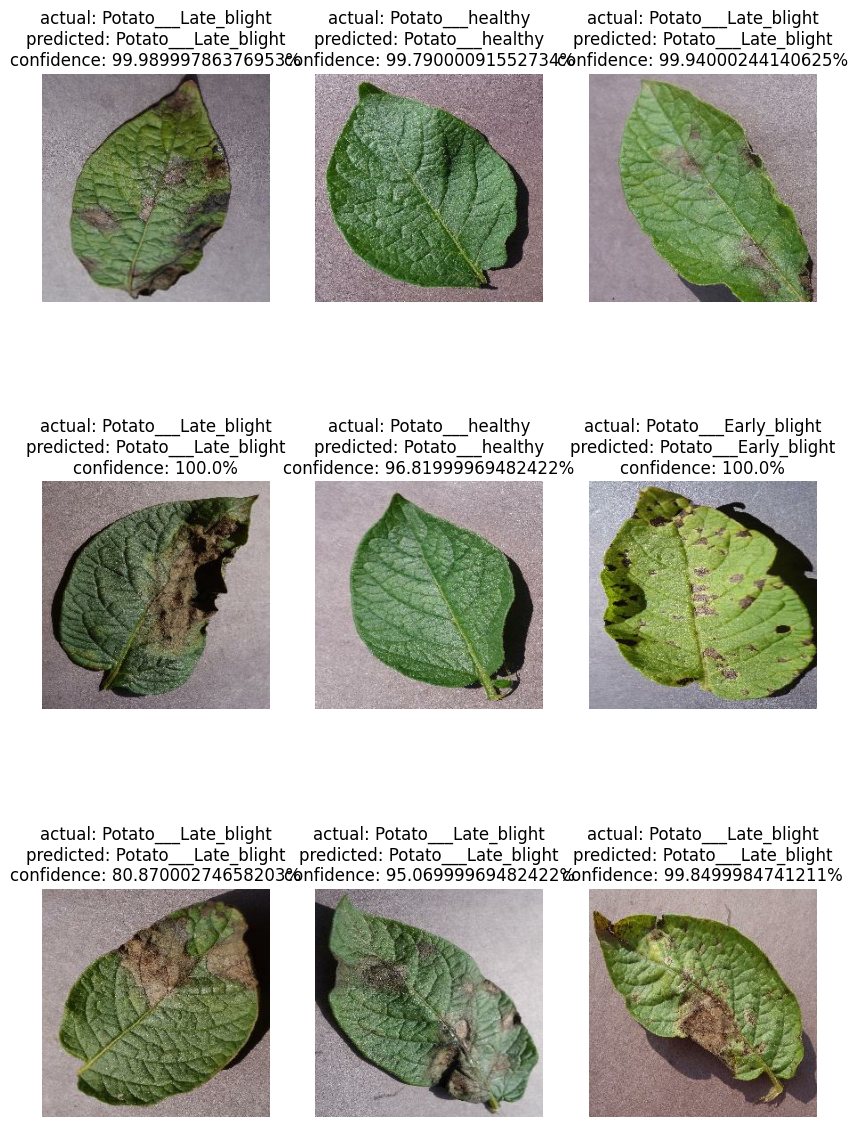

In [57]:
plt.figure(figsize=(10, 15))
for images , labels in test_ds.take(1):
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.axis("off")
        predicted_class, confidence = predict(model, images)
        actual_class = class_names[labels[i]]
        plt.title(f"actual: {actual_class}\npredicted: {predicted_class}\nconfidence: {confidence}%")
        

In [58]:
import os
model_version = max([int(x) for x in os.listdir("../models") + [0] ])+1

model_dir = f"../models/{model_version}"
os.makedirs(model_dir, exist_ok=True)

model.save(f"{model_dir}/model.keras")

In [ ]:
model.export("../models/potato_disease/1")
print("Done! SavedModel saved.")

INFO:tensorflow:Assets written to: ../models/potato_disease/1\assets


INFO:tensorflow:Assets written to: ../models/potato_disease/1\assets


Saved artifact at '../models/potato_disease/1'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name='keras_tensor_90')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  2397632302544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2397632301776: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2397632306000: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2397632307152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2397632306960: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2397632301392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2397632307728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2397632307344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2397632308112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2397632307920: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2397632308496: Tensor